First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   

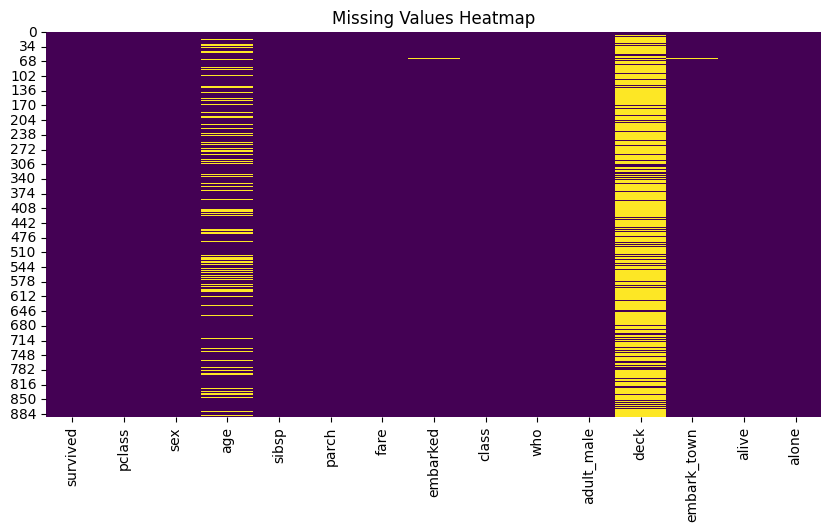

/tmp/ipykernel_2079/1568789074.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_2079/1568789074.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 


After Cleaning Missing Values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


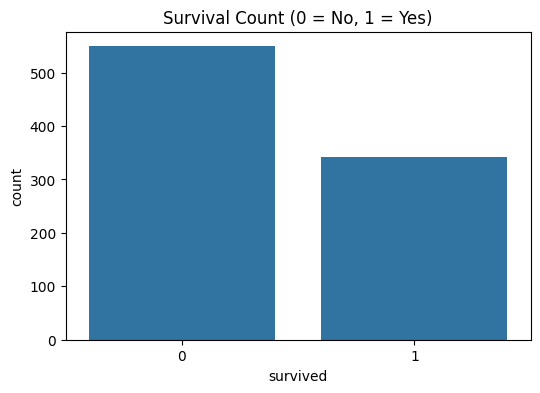

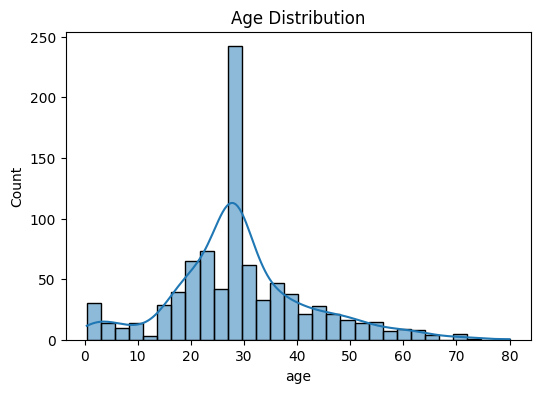

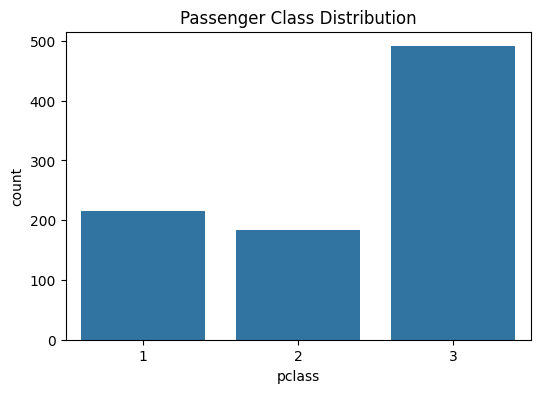

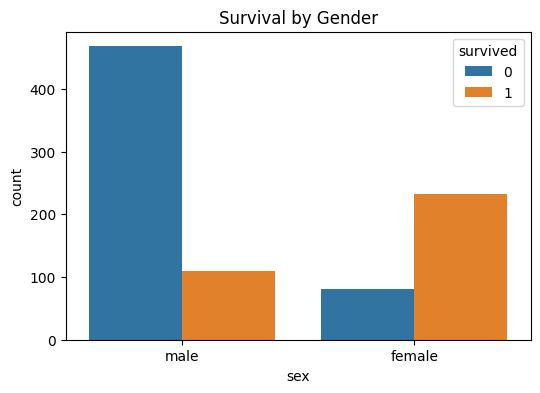

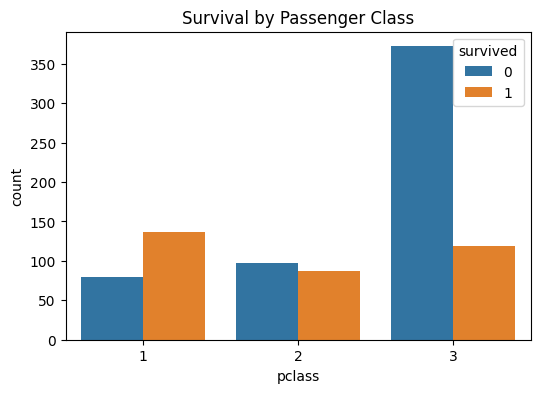

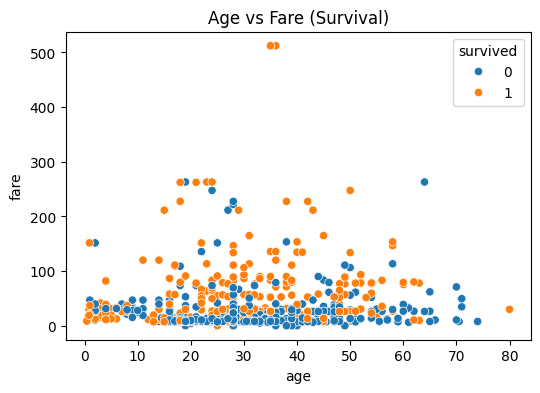

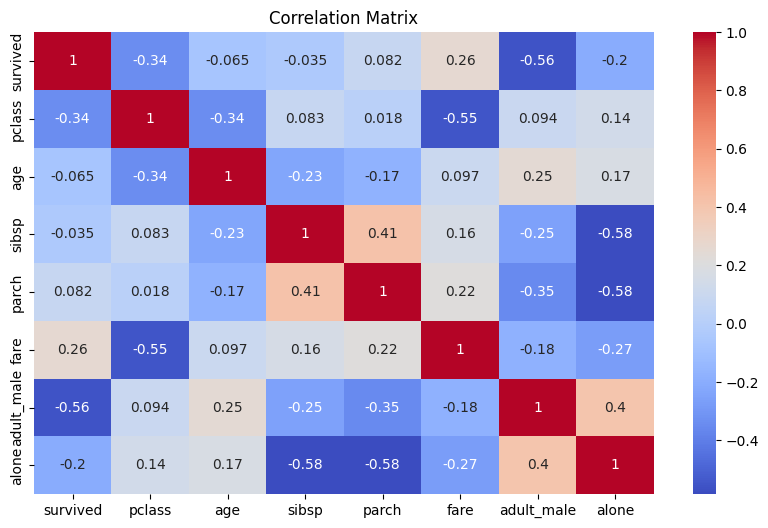


KEY INSIGHTS:
- Females had higher survival rate than males.
- First-class passengers survived more.
- Age and fare show weak correlation with survival.
- Passenger class is an important factor influencing survival.

EDA Completed Successfully!


In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 2. LOAD DATASET
# =========================
df = sns.load_dataset('titanic')

# Show first rows
print("First 5 rows:")
print(df.head())

# =========================
# 3. BASIC INFORMATION
# =========================
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# =========================
# 4. CHECK MISSING VALUES
# =========================
print("\nMissing Values:")
print(df.isnull().sum())

# Visualize missing data
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# =========================
# 5. DATA CLEANING
# =========================
# Fill missing age with median
df['age'].fillna(df['age'].median(), inplace=True)

# Fill embarked with mode
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop deck column (too many missing values)
df.drop(columns=['deck'], inplace=True)

print("\nAfter Cleaning Missing Values:")
print(df.isnull().sum())

# =========================
# 6. UNIVARIATE ANALYSIS
# =========================

# Survival count
plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df)
plt.title("Survival Count (0 = No, 1 = Yes)")
plt.show()

# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Passenger class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

# =========================
# 7. BIVARIATE ANALYSIS
# =========================

# Survival by gender
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Survival by class
plt.figure(figsize=(6,4))
sns.countplot(x='pclass', hue='survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

# Age vs Fare scatter
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.title("Age vs Fare (Survival)")
plt.show()

# =========================
# 8. CORRELATION ANALYSIS
# =========================

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# =========================
# 9. KEY INSIGHTS (PRINT)
# =========================
print("\nKEY INSIGHTS:")
print("- Females had higher survival rate than males.")
print("- First-class passengers survived more.")
print("- Age and fare show weak correlation with survival.")
print("- Passenger class is an important factor influencing survival.")

# =========================
# 10. FINAL SUMMARY
# =========================
print("\nEDA Completed Successfully!")